In [ ]:
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import pickle
import visutils
import cv2
from scipy.spatial import Delaunay
from mesh_utils import LH, Camera, cameras, actual_triangulate
from plot_utils import get_correspondences, load_fg

In [28]:
#frames are viewable in notebook
%matplotlib inline

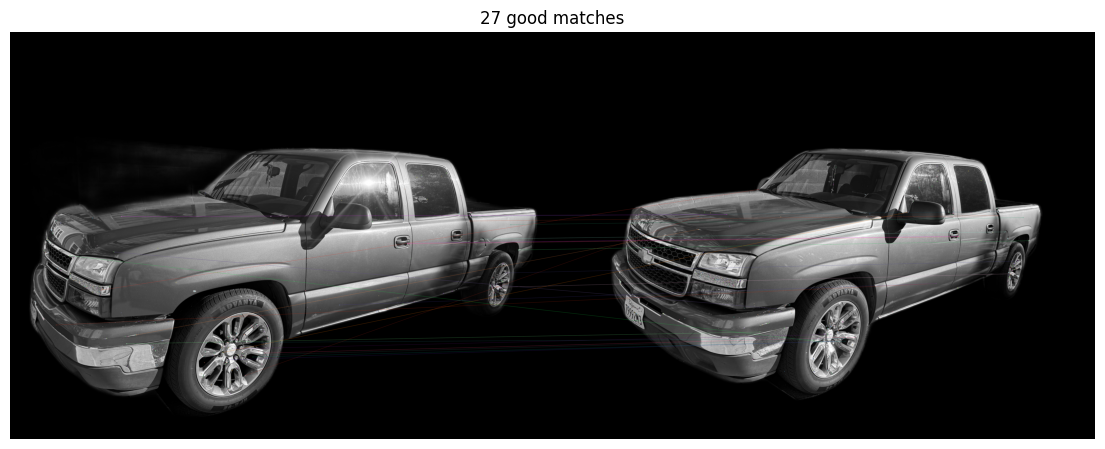

In [60]:
gray1, mask1 = load_fg('frames/rtruck1.png')
gray2, mask2 = load_fg('frames/rtruck2.png')

#feature matching from slides
#mask is to prevent background from being considered in feature selection
sift = cv2.SIFT_create(nfeatures=500)
kp1, des1 = sift.detectAndCompute(gray1, mask=mask1)
kp2, des2 = sift.detectAndCompute(gray2, mask=mask2)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

#filtering for good matches using an arbitrary ratio threshold (ensuring less ambiguity)
matches = [m for m, n in matches if m.distance / n.distance < 0.75]
#matches expressed as 2 x n arrays for easier processing in mesh reconstruction
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).T
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).T

#for visualization purposes
img3 = cv2.drawMatches(gray1, kp1, gray2, kp2, matches, None)

#converting back and visualizing
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 6))
plt.imshow(img3_rgb)
plt.title(f"{len(matches)} good matches")
plt.axis('off')
plt.show()

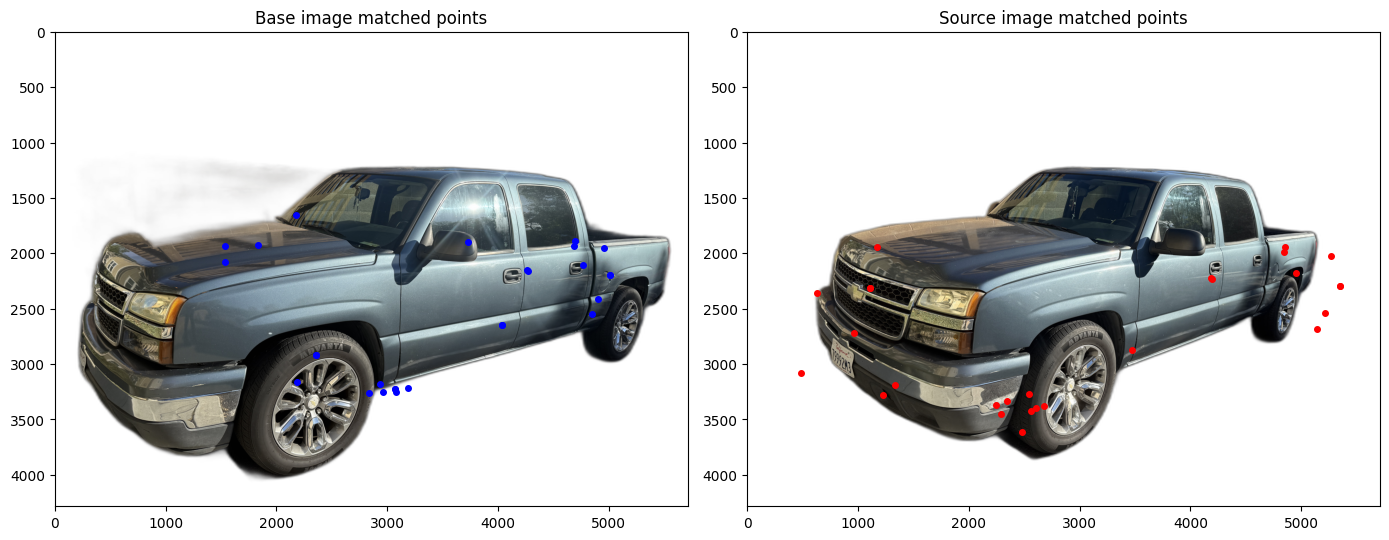

In [61]:
baseim = 0
imgs = [plt.imread('frames/rtruck1.png'), plt.imread('frames/rtruck2.png')]
srcpts, basepts = pts1, pts2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Base image — plot all N matched points
axes[0].imshow(imgs[0])
axes[0].plot(basepts[0], basepts[1], 'bo', markersize=4)  # [0]=all x, [1]=all y
axes[0].set_title('Base image matched points')

# Source image — plot all N corresponding points
axes[1].imshow(imgs[1])
axes[1].plot(srcpts[0], srcpts[1], 'ro', markersize=4)
axes[1].set_title('Source image matched points')

plt.tight_layout()
plt.show()

In [ ]:
#hardcoded dimensions from iPhone16 Pro Max, calculated pixel focal length from img dimensions
f_mm = 4.5
sensor_width, sensor_height = 9.84, 54
img_w, img_h = plt.imread('frames/rtruck1.png').shape[:2]
f_px = f_mm * (img_w/sensor_width)
cx, cy = img_w/2, img_h/2 #centered


#the Longuet-Higgins algorithm assumes the points are normalized for f and c
def normalise(pts2, f, cx, cy):# -> NDArray[Any]:
    x = (pts2[0] - cx)/f
    y = (pts2[1] - cy)/f
    return np.vstack([x, y])
#would also vstack np.ones(x.shape) for homogenous coords, but LH anyway does that

x_norm = normalise(srcpts,  f_mm, cx, cy)
y_norm = normalise(basepts, f_mm, cx, cy)

In [63]:
#t = translation, R = rotation, P & Q are the 3D point clouds corresponding to the Euclidean coordinates
t, R, P, Q = LH(x_norm, y_norm)

In [64]:
camL, camR = cameras(t, R, f_px, np.asarray((cx, cy)))

In [65]:
print(camL)

Camera : 
 f=1959.1463414634147 
 c=[       2142        2856] 
 R=[[          1           0           0]
 [          0           1           0]
 [          0           0           1]] 
 t = [[          0           0           0]]


In [66]:
print(camR)

Camera : 
 f=1959.1463414634147 
 c=[       2142        2856] 
 R=[[   -0.57914  0.00089293     0.81523]
 [    0.81517    -0.01061     0.57912]
 [  0.0091666     0.99994   0.0054168]] 
 t = [[    0.58861   0.0025804    -0.80842]]


In [ ]:
#just some renaming to make life easier
pts2L, pts2R = pts1, pts2
pts3 = actual_triangulate(pts2L, camL, pts2R, camR)

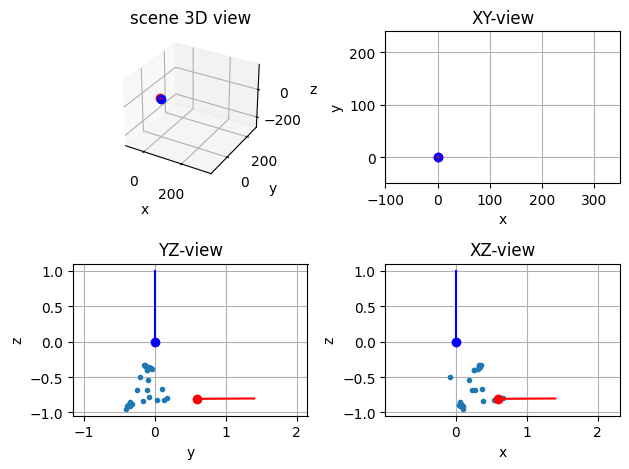

In [71]:
# Add your visualization code here.  As we have done previously it is good to visualize different
# 2D projections XY, XZ, YZ and well as a 3D version
# visualize the left and right image overlaid
fig = plt.figure()

# generate coordinates of a line segment running from the center
# of the camera to 1 unit in front of the camera
lookL = np.hstack((camL.t, camL.t + camL.R @ np.array([[0,0,1]]).T))
lookR = np.hstack((camR.t, camR.t + camR.R @ np.array([[0,0,1]]).T))


#visualize 3D layout of points, camera positions
# and the direction the camera is pointing
ax = fig.add_subplot(2,2,1,projection='3d')
ax.set_xlim([-100, 350])
ax.set_ylim([-50, 200])
ax.set_zlim([-200, 100])
ax.plot(pts3[0,:],pts3[1,:],pts3[2,:],'.')
ax.plot(camL.t[0],camL.t[1],camL.t[2],'ro')
ax.plot(camR.t[0],camR.t[1],camR.t[2],'bo')
ax.plot(lookL[0,:],lookL[1,:],lookL[2,:],'b')
ax.plot(lookR[0,:],lookR[1,:],lookR[2,:],'r')
visutils.set_axes_equal_3d(ax)
visutils.label_axes(ax)
plt.title('scene 3D view')


# overhead view showing points, camera
# positions, and direction camera is pointed
ax = fig.add_subplot(2,2,3)
ax.set_xlim([-50, 200])
ax.set_ylim([-200, 100])
ax.plot(pts3[1,:],pts3[2,:],'.')
ax.plot(camL.t[0],camL.t[2],'bo')
ax.plot(lookL[0,:],lookL[2,:],'b')
ax.plot(camR.t[0],camR.t[2],'ro')
ax.plot(lookR[0,:],lookR[2,:],'r')
plt.axis('equal')
plt.grid()
plt.xlabel('y')
plt.ylabel('z')
plt.title('YZ-view')


# overhead view showing points, camera
# positions, and direction camera is pointed
ax = fig.add_subplot(2,2,4)
ax.set_xlim([-100, 350])
ax.set_ylim([-200, 100])
ax.plot(pts3[0,:],pts3[2,:],'.')
ax.plot(camL.t[0],camL.t[2],'bo')
ax.plot(lookL[0,:],lookL[2,:],'b')
ax.plot(camR.t[0],camR.t[2],'ro')
ax.plot(lookR[0,:],lookR[2,:],'r')
plt.axis('equal')
plt.grid()
plt.xlabel('x')
plt.ylabel('z')
plt.title('XZ-view')

ax = fig.add_subplot(2,2,2)
ax.set_xlim([-100, 350])
ax.set_ylim([-50, 240])
ax.plot(pts3[0,:],pts3[1,:],'.')
ax.plot(camL.t[0],camL.t[1],'ro')
ax.plot(camR.t[0],camR.t[1],'bo')
ax.plot(lookL[0,:],lookL[1,:],'b')
ax.plot(lookR[0,:],lookR[1,:],'r')
plt.title('XY-view')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')

fig.tight_layout()
#the cameras seem to be pointing away from the point cloud? huh?

In [ ]:
# Mesh cleanup parameters

# Specify limits along the x,y and z axis of a box containing the object
# we will prune out triangulated points outside these limits
# boxlimits = np.array([0, 270, 70, 300, -140, 30])

# # Specify a longest allowed edge that can appear in the mesh. Remove triangles
# # from the final mesh that have edges longer than this value
trithresh = 12

tri = Delaunay(pts2L.T).simplices

#
# triangle pruning
#
triangles = []
for t_idx in range(len(tri)):
    v0, v1, v2 = tri[t_idx]
    edge01 = np.linalg.norm(pts3[:, v1] - pts3[:, v0])
    edge12 = np.linalg.norm(pts3[:, v2] - pts3[:, v1])
    edge20 = np.linalg.norm(pts3[:, v0] - pts3[:, v2])
    max_edge = max(edge01, edge12, edge20)
    if max_edge <= trithresh:
        triangles.append(t_idx)

tri = tri[triangles]
#
# remove any points which are not referenced in any triangle
#
vertices_used = np.unique(tri.ravel())
pts3 = pts3[:, vertices_used]
pts2L = pts2L[:, vertices_used]
pts2R = pts2R[:, vertices_used]

old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(vertices_used)}
tri = tri[:, [0, 2, 1]]
tri_final = np.array([[old_to_new[v] for v in triangle] for triangle in tri])

tri = tri_final

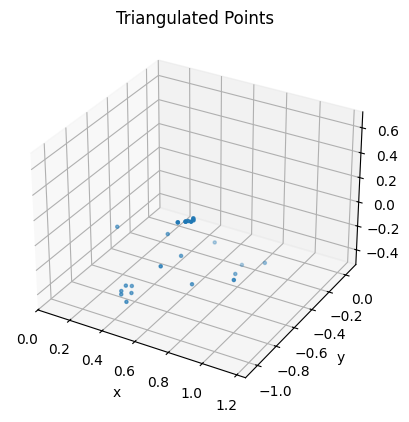

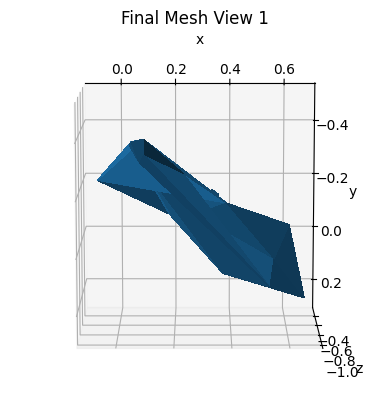

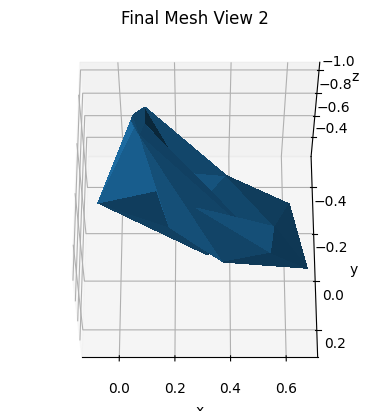

In [80]:
# vis code 

fig_tri = plt.figure()
ax_tri = fig_tri.add_subplot(111, projection='3d')
ax_tri.scatter(pts3[0,:], pts3[1,:], pts3[2,:], s=20, marker='.')
ax_tri.set_xlim([0, 1.25])
ax_tri.set_ylim([-1, 0])
ax_tri.set_zlim([0, 0.2])
visutils.set_axes_equal_3d(ax_tri)
visutils.label_axes(ax_tri)
ax_tri.set_title('Triangulated Points')
plt.show()

fig1 = plt.figure()
ax = fig1.add_subplot(111, projection='3d')
ax.plot_trisurf(pts3[0,:], pts3[1,:], pts3[2,:], triangles=tri,antialiased=False)
ax.view_init(azim=-90,elev=-80)  #set the camera viewpointn
visutils.set_axes_equal_3d(ax)
visutils.label_axes(ax)
plt.title('Final Mesh View 1')
plt.show()

fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')
ax.plot_trisurf(pts3[0,:], pts3[1,:], pts3[2,:], triangles=tri,antialiased=False)
ax.view_init(azim=-90,elev=-120)  #set the camera viewpointn
visutils.set_axes_equal_3d(ax)
visutils.label_axes(ax)
plt.title('Final Mesh View 2')
plt.show()

# show_trisurf is a bit slow to update with a very large mesh.
# An alternative is to use the trimesh library (https://github.com/mikedh/trimesh)
# to install trimesh, try conda install -c conda-forge trimesh
# and then import trimesh into your notebook
#
# A nice feature is that it will create a plot which is more interactive (so you can
# drag with the mouse pointer to rotate the 3D mesh to view from different directions)
#
import trimesh 
mesh = trimesh.Trimesh(vertices=pts3.T,faces=tri[:,[0,2,1]])
matrix_x = trimesh.transformations.rotation_matrix(np.deg2rad(160), [0, 0, 1])
matrix_y = trimesh.transformations.rotation_matrix(np.deg2rad(40), [0, 1, 0])
matrix_z = trimesh.transformations.rotation_matrix(np.deg2rad(50), [1, 0, 0])
mesh.apply_transform(matrix_x)
mesh.apply_transform(matrix_y)
mesh.apply_transform(matrix_z)
mesh.show()